<a href="https://colab.research.google.com/github/lucaser9898/sovereign-funds-rl-portfolio/blob/main/Calcolo_portafoglio_Azionario.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()



Saving indici_borsa_unificati.csv to indici_borsa_unificati.csv


In [ ]:
import pandas as pd

# Carica il file CSV
df = pd.read_csv("indici_borsa_unificati.csv")

# Visualizza le prime righe
df.head()


,Date,MSCI ARGENTINA,MSCI AUSTRALIA,MSCI AUSTRIA,MSCI BAHRAIN DOMESTIC,MSCI BAHRAIN,MSCI BANGLADESH,MSCI BELGIUM,MSCI BOSNIA AND HERZEGOVINA,MSCI BOTSWANA,...,MSCI WORLD ex CANADA,MSCI WORLD ex EMU,MSCI WORLD ex EUROPE,MSCI WORLD ex ISRAEL,MSCI WORLD ex UK,MSCI WORLD ex USA,MSCI WORLD,MSCI ZHONG HUA WITH CHINA ALL SHARES,MSCI ZHONG HUA WITH PARTIAL A SHARES,MSCI ZHONG HUA
0,2001-01,131.297811,139.132918,104.026606,NaN,NaN,NaN,87.734228,NaN,NaN,...,138.274801,139.959541,142.702016,NaN,141.414146,140.191243,139.603490,NaN,NaN,106.893539
1,2001-02,107.577705,134.273848,112.032295,NaN,NaN,NaN,88.826122,NaN,NaN,...,128.259070,129.994215,132.324041,NaN,130.620596,130.541443,129.228110,NaN,NaN,103.581596
2,2001-03,114.241448,124.858065,110.973491,NaN,NaN,NaN,84.079523,NaN,NaN,...,124.716690,126.614749,129.176202,NaN,126.625704,126.590783,125.579824,NaN,NaN,94.791319
3,2001-04,111.301952,139.149245,113.240142,NaN,NaN,NaN,83.120875,NaN,NaN,...,133.531632,135.363800,138.462634,NaN,135.722068,135.008542,134.449047,NaN,NaN,96.904973
4,2001-05,118.008203,146.370569,111.078967,NaN,NaN,NaN,82.914129,NaN,NaN,...,137.751773,141.322452,145.414495,NaN,140.423773,136.564294,138.794891,NaN,NaN,101.269076


In [ ]:
dati=pd.concat([df],axis=1).sort_values(by="Date")
dati=dati.iloc[:,~dati.columns.duplicated()] # elimino i duplicati
dati.set_index('Date', inplace=True) # Set the 'Date' column as the index
dati.info()

<class 'pandas.core.frame.DataFrame'>
Index: 295 entries, 1999-01 to 2023-07
Columns: 302 entries, MSCI ARGENTINA to MSCI ZHONG HUA
dtypes: float64(302)
memory usage: 698.3+ KB


In [ ]:

dati.loc["2022-03":,"MSCI RUSSIA VALUE"].fillna(0.001, inplace=True)
dati.loc["2022-03":,"MSCI RUSSIA GROWTH"].fillna(0.001, inplace=True)

/tmp/ipython-input-4-2443934506.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dati.loc["2022-03":,"MSCI RUSSIA VALUE"].fillna(0.001, inplace=True)
/tmp/ipython-input-4-2443934506.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

In [ ]:
dati.fillna(method="ffill",limit=6,inplace=True)

/tmp/ipython-input-5-3223504453.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dati.fillna(method="ffill",limit=6,inplace=True)


In [ ]:
# dati.drop(["2023-07","2023-06","2023-05"],axis=0,inplace=True)
# dati.drop(["2023-07"],axis=0,inplace=True)

In [ ]:
etf=["MSCI RUSSIA VALUE","MSCI USA", "MSCI JAPAN", "MSCI UNITED KINGDOM", "MSCI CHINA", "MSCI FRANCE", "MSCI CANADA", "MSCI SWITZERLAND", "MSCI GERMANY",
     "MSCI AUSTRALIA", "MSCI INDIA", "MSCI TAIWAN", "MSCI KOREA", "MSCI NETHERLANDS", "MSCI SWEDEN", "MSCI DENMARK", "MSCI HONG KONG", "MSCI BRAZIL",
     "MSCI ITALY", "MSCI SPAIN", "MSCI FINLAND", "MSCI SOUTH AFRICA", "MSCI SINGAPORE", "MSCI MEXICO", "MSCI ISRAEL", "MSCI INDONESIA",
     "MSCI THAILAND", "MSCI MALAYSIA", "MSCI BELGIUM", "MSCI UNITED ARAB EMIRATES", "MSCI NEW ZEALAND", "MSCI PHILIPPINES", "MSCI QATAR",
     "MSCI CHILE", "MSCI PORTUGAL", "MSCI POLAND", "MSCI IRELAND", "MSCI Greece Rebased Index", "MSCI KUWAIT", "MSCI TURKEY", "MSCI AUSTRIA", "MSCI HUNGARY",
     "MSCI EGYPT", "MSCI COLOMBIA"]
percentage=[1.5*dati.loc[dati.index[-1],"MSCI RUSSIA VALUE"]/dati.loc["2022-01","MSCI RUSSIA VALUE"],60.6, 6.3, 3.9, 3.2, 2.9, 2.5, 2.4, 2.1, 2.0, 1.8, 1.7, 1.3, 1.2, 0.8, 0.7, 0.7, 0.7, 0.7, 0.6, 0.3, 0.3, 0.3, 0.3, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
print(len(percentage) == len(etf) and len(etf) == len(dati[etf].iloc[0])) # Controllo che gli ETF e le percentuali coincidano in lunghezza, e che tutti gli etf siano contenuti nei dati


False


In [ ]:
dati2=dati[etf].dropna(how="all",axis=0).copy()

In [ ]:
dati2

,MSCI RUSSIA VALUE,MSCI USA,MSCI JAPAN,MSCI UNITED KINGDOM,MSCI CHINA,MSCI FRANCE,MSCI CANADA,MSCI SWITZERLAND,MSCI GERMANY,MSCI AUSTRALIA,...,MSCI PORTUGAL,MSCI POLAND,MSCI IRELAND,MSCI Greece Rebased Index,MSCI KUWAIT,MSCI TURKEY,MSCI AUSTRIA,MSCI HUNGARY,MSCI EGYPT,MSCI COLOMBIA
Date,,,,,,,,,,,,,,,,,,,,,
1999-01,NaN,107.835743,104.148834,102.329968,NaN,106.400575,111.965322,100.975056,105.110024,109.626282,...,107.503437,NaN,105.139144,118486.967177,NaN,NaN,97.216926,NaN,NaN,NaN
1999-02,NaN,108.410795,105.380212,108.212951,NaN,102.861165,109.226011,101.059233,99.762066,110.532450,...,103.670350,NaN,108.534914,120992.977530,NaN,NaN,106.152064,NaN,NaN,NaN
1999-03,NaN,114.783645,122.014403,113.463298,NaN,106.527973,115.634686,101.610812,98.689626,117.109713,...,98.299846,NaN,108.491231,118772.657006,NaN,NaN,107.615208,NaN,NaN,NaN
1999-04,NaN,121.335428,129.709081,120.265498,NaN,111.557174,129.999097,103.415185,107.247695,131.740817,...,94.090217,NaN,113.761872,127793.880064,NaN,NaN,114.491142,NaN,NaN,NaN
1999-05,NaN,120.192568,124.171663,115.251312,NaN,110.540506,128.248934,99.608672,102.184902,122.660220,...,97.501035,NaN,102.152191,135399.442235,NaN,NaN,101.619984,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03,0.001,483.829808,234.344411,243.897563,432.971769,342.072752,653.451872,407.673205,256.592123,716.662578,...,104.537223,124.465294,91.698727,7680.394871,1632.482789,157.239311,220.578414,332.022854,477.918244,1490.362766
2023-04,0.001,482.047167,231.463159,252.776878,404.115072,352.292664,662.192719,426.136687,261.144739,706.701656,...,107.079757,139.014515,92.826069,7833.375724,1650.109259,146.784120,229.020227,359.045994,493.431571,1546.166276
2023-05,0.001,502.163466,244.151134,244.570534,383.195869,337.584389,648.211895,421.202966,255.267379,696.912347,...,100.147001,138.269718,92.090455,8816.327453,1590.659157,149.609128,216.827302,384.044384,509.333937,1494.449274


In [ ]:
# mostriamo la media mensile annualizzata dei rendimenti
(round((dati2.pct_change(1).mean()+1)**12-1,4)*100).sort_values()

,0
MSCI Greece Rebased Index,-4.36
MSCI PORTUGAL,1.34
MSCI IRELAND,2.11
MSCI ISRAEL,3.07
MSCI BELGIUM,3.13
MSCI UNITED ARAB EMIRATES,3.67
MSCI ITALY,3.96
MSCI UNITED KINGDOM,4.89
MSCI JAPAN,5.05
MSCI SPAIN,5.57


In [ ]:
# mostriamo la dev std decennale
(round(dati2.pct_change(120).std()*100)).sort_values()

,0
MSCI Greece Rebased Index,18.0
MSCI PORTUGAL,27.0
MSCI SPAIN,30.0
MSCI ISRAEL,32.0
MSCI ITALY,40.0
MSCI CANADA,42.0
MSCI UNITED KINGDOM,44.0
MSCI AUSTRIA,46.0
MSCI AUSTRALIA,51.0
MSCI QATAR,53.0


In [ ]:
import numpy as np # Import the numpy library
# mostriamo sharpe ratio
round(((dati2.pct_change(1).mean()+1)**12-1)/(dati2.pct_change(120).std()/np.sqrt(10)),3).sort_values()

,0
MSCI Greece Rebased Index,-0.778
MSCI IRELAND,0.070
MSCI COLOMBIA,0.076
MSCI UNITED ARAB EMIRATES,0.097
MSCI EGYPT,0.135
MSCI PHILIPPINES,0.154
MSCI PORTUGAL,0.155
MSCI CHILE,0.163
MSCI BELGIUM,0.169
MSCI INDONESIA,0.172


In [ ]:
# quanti=10
# colormap = plt.cm.gist_ncar
# plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.jet(np.linspace(0, 1, quanti))))
# x = np.arange(10)
# labels = []
# plt.rcParams["figure.figsize"] = (20,10)
# for x in dati2.columns[:quanti]:
# #    plt.plot((dati2.loc["2000-07":"2009-12",x]/dati2.loc["2000-07",x]))
#     plt.plot((dati2.loc[:,x]/dati2.loc["2023-06",x]))
#     plt.plot((dati2.loc[:,x]))
#     labels.append(x)
# plt.legend(labels, ncol=4, loc='upper center',
#        bbox_to_anchor=[0.5, 1.1],
#        columnspacing=1.0, labelspacing=0.0,
#        handletextpad=0.0, handlelength=1.5,
#        fancybox=True, shadow=True)

# plt.show()
# # ATTENZIONE che sono arminizzati A DESTRA dato che non hanno un inizio uguale

In [ ]:
ricalcolo_pesi=True
N=1
results=pd.DataFrame()
tf=dati2.iloc[-1]
for i1 in range(len(dati2.index)-12*N):
    i2=i1+12*N
    t1=dati2.iloc[i1].dropna()
    t2=dati2.iloc[i2].dropna()
    validi=[x for x in t1.index if x in t2.index]
    results.loc[dati2.index[i1],"Equally weighted"]=(sum(t2[validi]/t1[validi])/len(validi))**(1/N)-1 # banale media semplice
    pesi=[percentage[k] for k in [j for (j, item) in enumerate(etf) if item in validi]]
    pesi_ritracciati=list(pesi)
    if ricalcolo_pesi:
        pesi_ritracciati=list(pesi*t1[validi]/tf[validi])
    #    pesi_ritracciati = np.sqrt( np.array( pesi_ritracciati ) ) # pesi sotto radice quadrata
    #    pesi_ritracciati=1/np.array(pesi_ritracciati) # pesi ROVESCIATI
    pesi_ritracciati=np.array(pesi_ritracciati)/sum(pesi_ritracciati)
    # print(validi,pesi_ritracciati)
    results.loc[dati2.index[i1],"Value weighted"]=(np.dot(t2[validi]/t1[validi],pesi_ritracciati))**(1/N)-1 # media pesata
    # facciamo equally weighted ribilanciato annualmente
    valore=100
    assegnazione=valore/len(validi)
    quantita=assegnazione/t1
    salto=False
    for i in range(i1,i2+1,12):
        if len(quantita)==len(dati2[validi].iloc[i].dropna()):
            valore=np.dot(quantita,dati2[validi].iloc[i].dropna())
            assegnazione=valore/len(validi)
            quantita=assegnazione/dati2[validi].iloc[i].dropna()
        else:
            salto=True
            break
    if not salto:
        results.loc[dati2.index[i1],"Equally weighted rebalanced yearly"]=(valore/100)**(1/N)-1
    # facciamo equally weighted ribilanciato mensilmente
#valore = 10
#assegnazione = valore / len(validi)
#quantita = assegnazione / t1
#salto = False

#for i in range(i1, i2 + 1):
#    if len(quantita) == len(dati2[validi].iloc[i].dropna()):
#        valore = np.dot(quantita, dati2[validi].iloc[i].dropna())
#        assegnazione = valore / len(validi)
#        quantita = assegnazione / dati2[validi].iloc[i].dropna()
#    else:
#        salto = True
#        break

#if not salto:
#    results.loc[dati2.index[i1], "Equally weighted rebalanced monthly"] = (valore / 100) ** (1 / N) - 1


In [ ]:
# # Value weighted rebalanced yearly
# valore = 100
# pesi_iniziali = t1[validi] / t1[validi].sum()  # pesi iniziali
# quantita = (valore * pesi_iniziali) / t1[validi]

# salto = False

# for i in range(i1, i2 + 1, 12):  # ogni 12 mesi
#     try:
#         prezzi_attuali = dati2[validi].iloc[i].dropna()

#         # Condizione robusta: procedi solo se hai tutti i dati per i validi asset
#         if not set(validi).issubset(prezzi_attuali.index):
#             salto = True
#             break

#         valore = np.dot(quantita, prezzi_attuali)

#         # Ribilancia con nuovi prezzi
#         nuovi_pesi = prezzi_attuali / prezzi_attuali.sum()
#         quantita = (valore * nuovi_pesi) / prezzi_attuali

#     except Exception as e:
#         salto = True
#         break

# # Se non ci sono stati salti, salva il risultato
# if not salto:
#     results.loc[dati2.index[i1], "Value weighted rebalanced yearly"] = (valore / 100) ** (1 / N) - 1
#     # print(f"Calcolata riga {i1}: valore finale = {valore}" if not salto else f"Salto riga {i1}")





In [ ]:
valore = 100  # capitale iniziale
valori_portafoglio = []  # salviamo l'evoluzione del portafoglio

for i in range(len(dati2.index) - 1):
    # Prezzi attuali e successivi
    t_attuale = dati2.iloc[i].dropna()
    t_successivo = dati2.iloc[i+1].dropna()

    # Troviamo ETF presenti sia oggi che nel mese successivo
    validi = [x for x in t_attuale.index if x in t_successivo.index]

    if len(validi) == 0:
        valori_portafoglio.append(np.nan)
        continue

    # Pesi value weighted: proporzionali al valore dell'ETF
    pesi = t_attuale[validi] / sum(t_attuale[validi])

    # Calcoliamo il rendimento del mese successivo
    rendimento_mensile = np.dot(t_successivo[validi] / t_attuale[validi], pesi) - 1

    # Aggiorniamo il valore del portafoglio
    valore = valore * (1 + rendimento_mensile)
    valori_portafoglio.append(valore)

# Ricreiamo il DataFrame dei risultati
result_vw_monthly = pd.DataFrame({
    "Date": dati2.index[1:],  # da secondo mese in poi
    "Value_Weighted_Monthly_Rebalanced": valori_portafoglio
})


In [ ]:
# results

In [ ]:
results.describe()

,Equally weighted,Value weighted,Equally weighted rebalanced yearly
count,283.000000,283.000000,283.000000
mean,0.084387,0.067960,0.084387
std,0.201217,0.179339,0.201217
min,-0.471757,-0.424365,-0.471757
25%,-0.049156,-0.029115,-0.049156
50%,0.092335,0.088735,0.092335
75%,0.211206,0.182831,0.211206
max,0.698999,0.535832,0.698999


In [ ]:
print(results.tail())  # oppure head()


         Equally weighted  Value weighted  Equally weighted rebalanced yearly
2022-03         -0.023281       -0.051403                           -0.023281
2022-04         -0.009283       -0.023967                           -0.009283
2022-05          0.002483        0.014341                            0.002483
2022-06          0.112702        0.117225                            0.112702
2022-07          0.089355        0.045107                            0.089355


<Axes: >

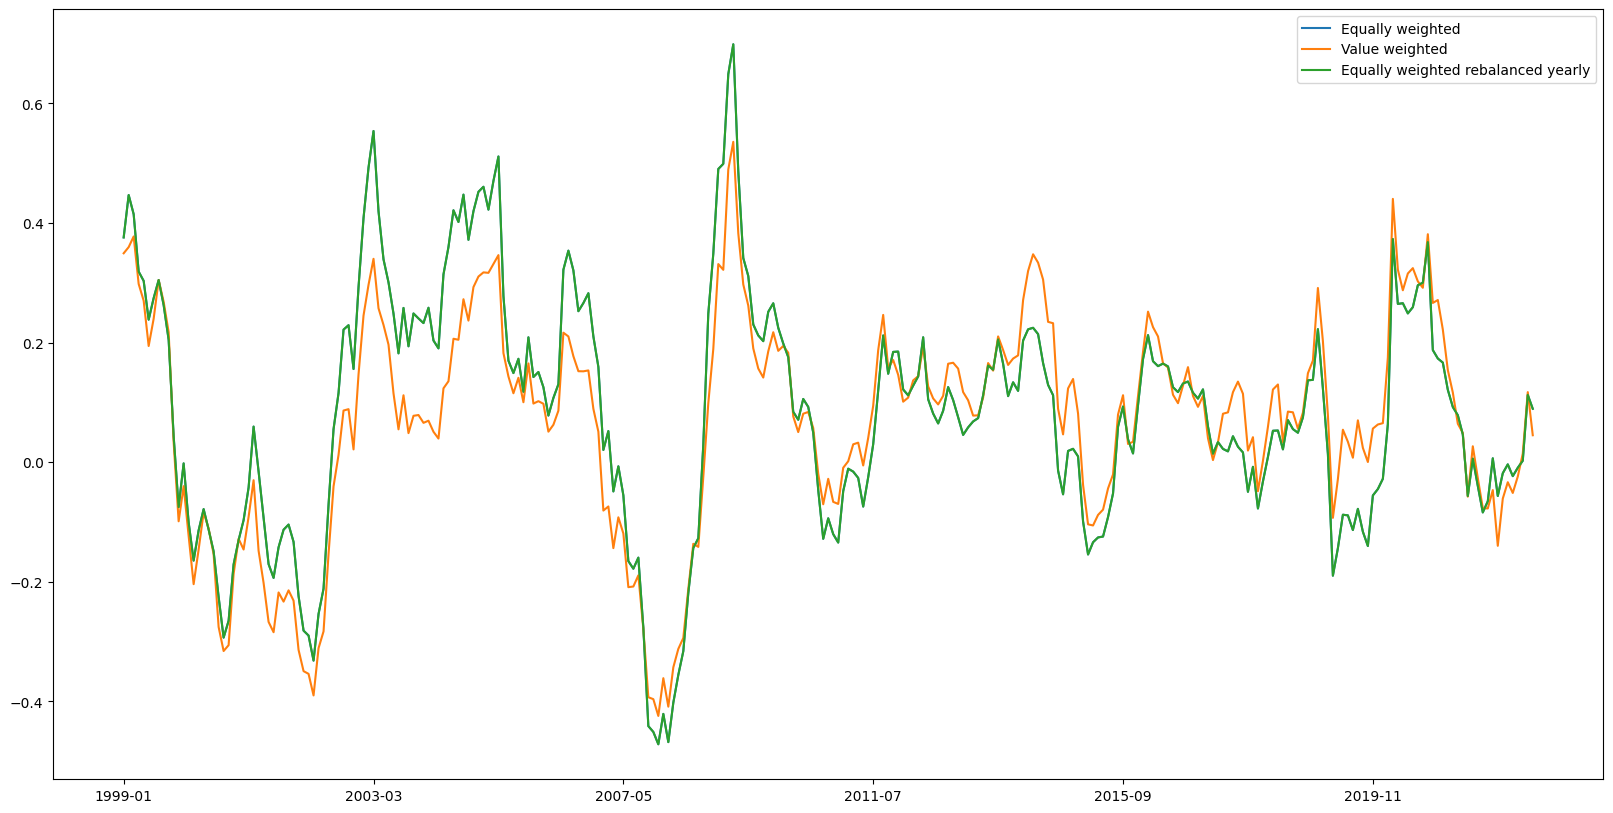

In [ ]:
results.plot(figsize=(20,10))

<Axes: >

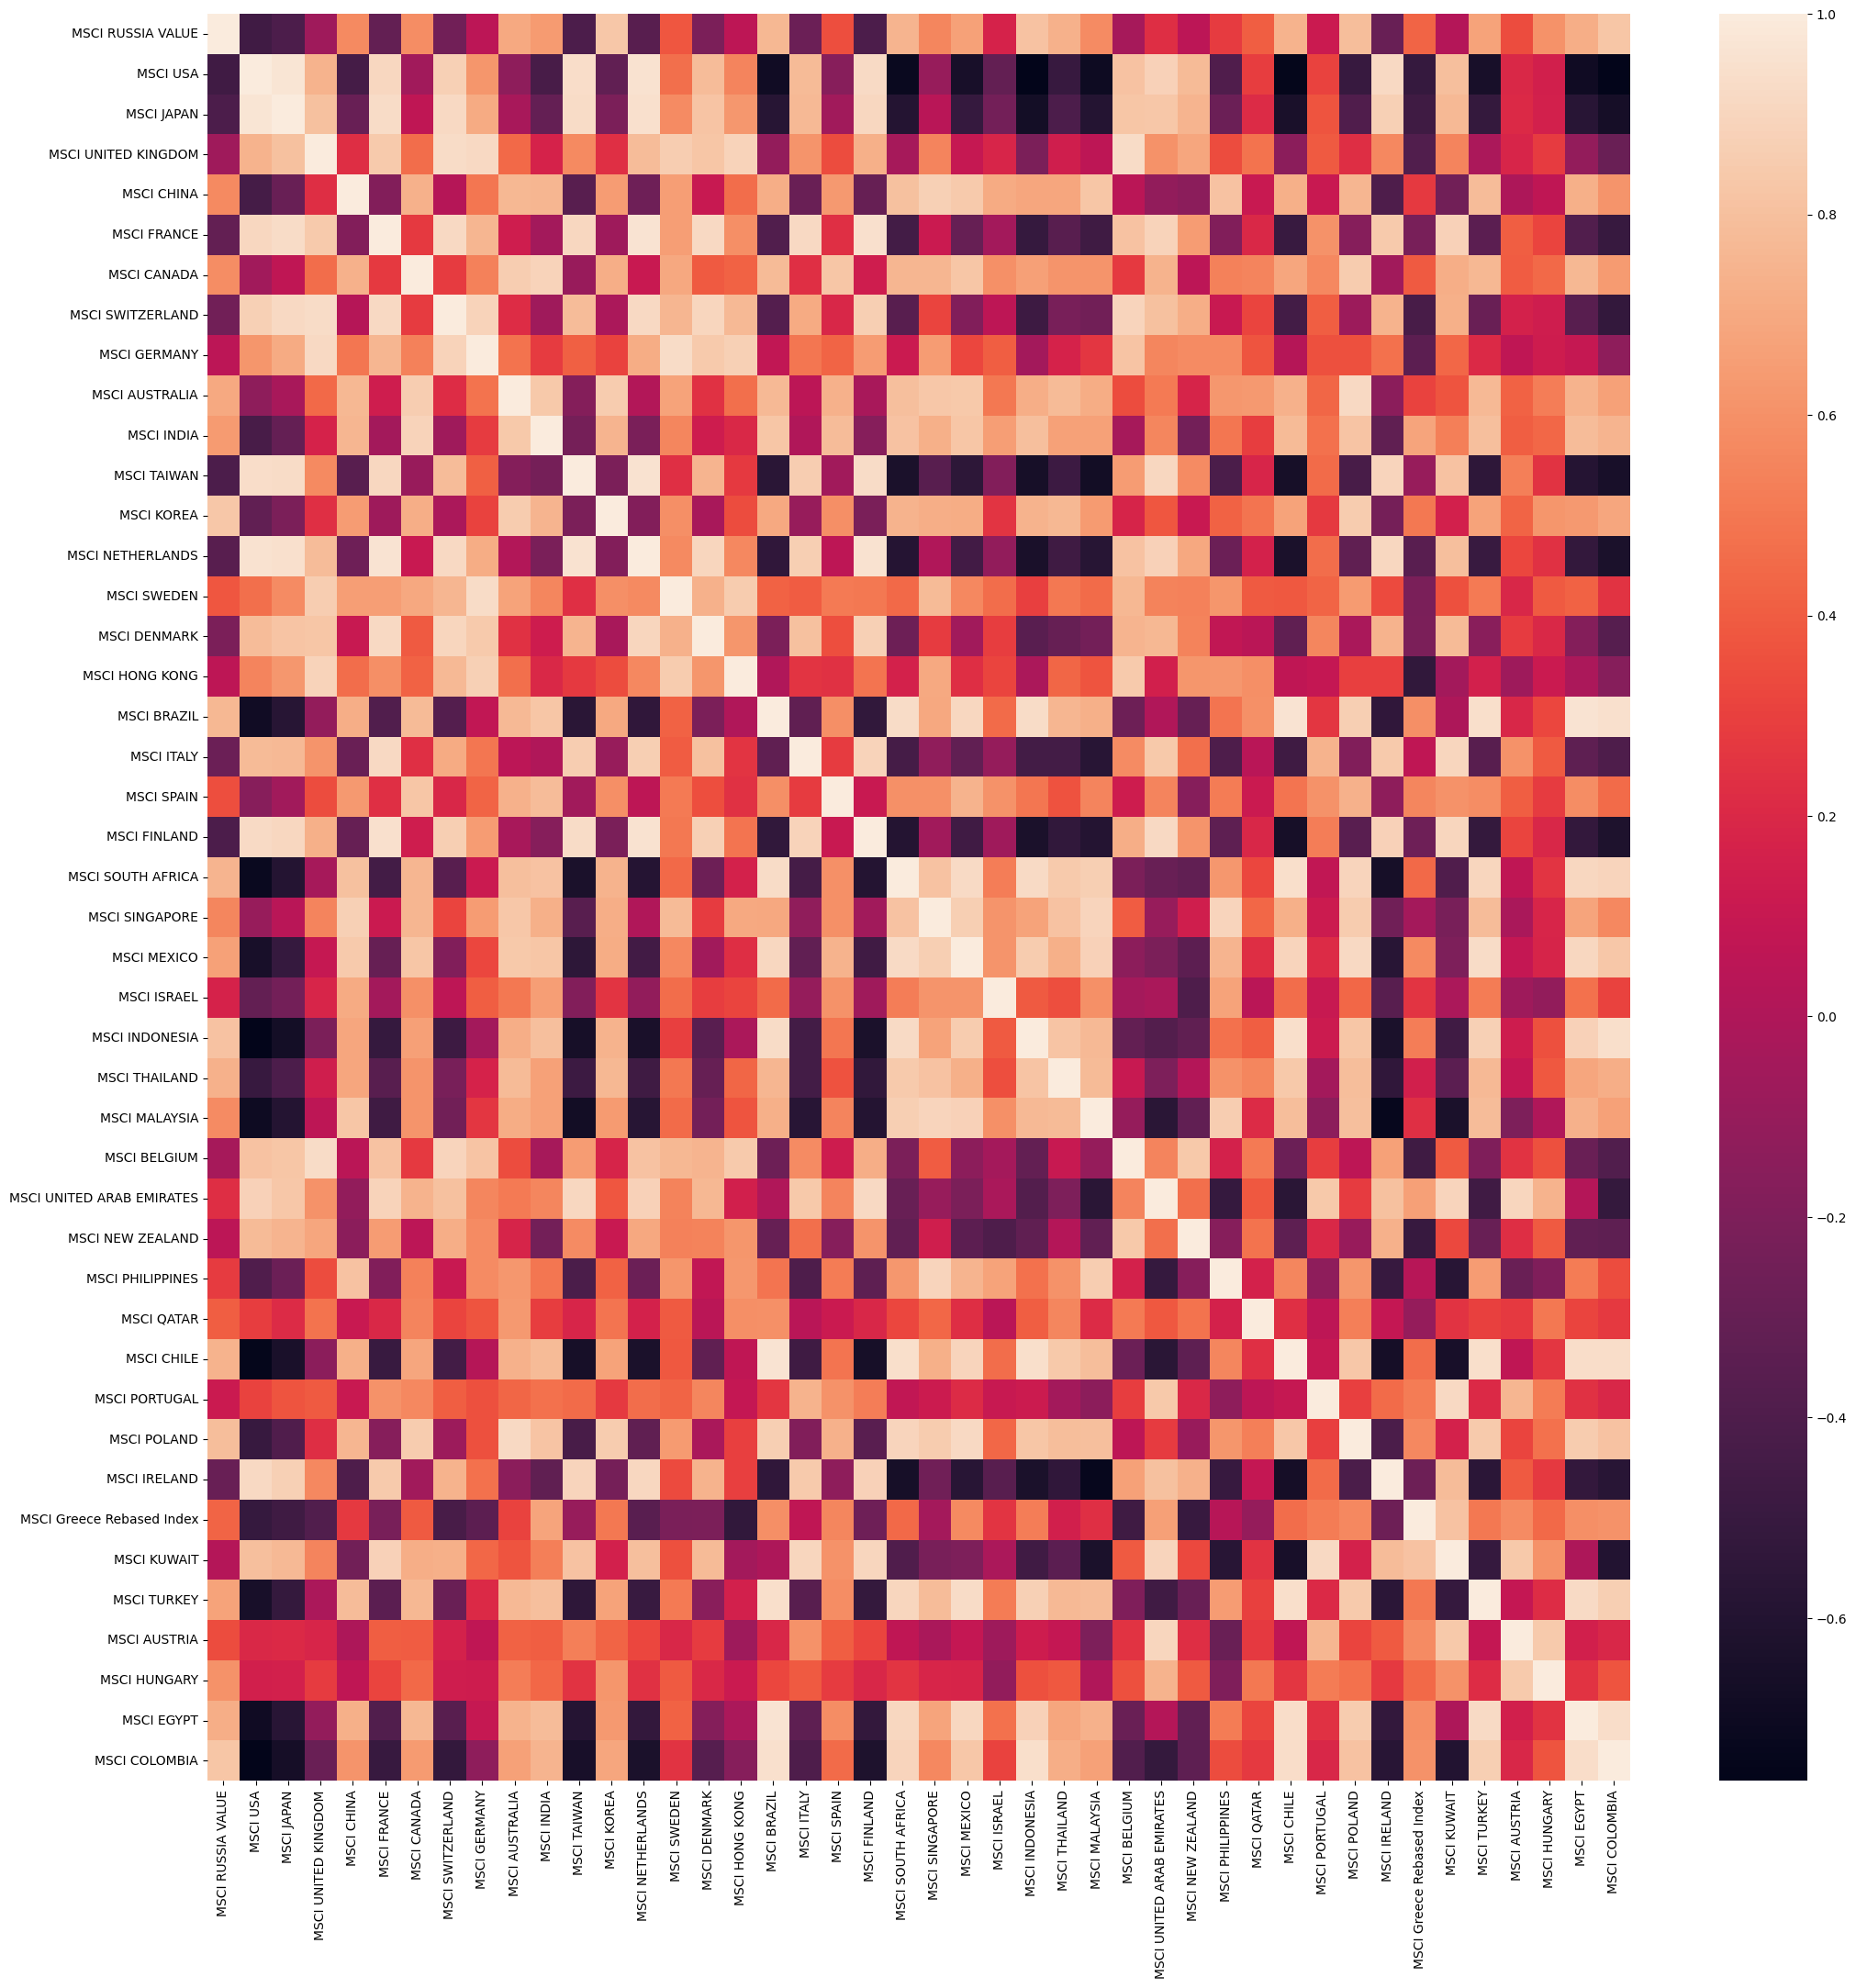

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize = (25,25))
sns.heatmap(dati2.pct_change(120).corr())